# 📓 06 — Forecasting

## Objetivo

Utilizar o modelo LightGBM selecionado no Notebook 05 para gerar previsões futuras de vendas.

Nesta etapa, serão carregados o modelo final e seus metadados, além da base histórica necessária para a construção das variáveis temporais utilizadas durante a previsão.

As previsões serão geradas para um horizonte futuro definido, utilizando uma abordagem recursiva para atualização das variáveis de atraso e médias móveis.

In [1]:
# ============================================================
# IMPORTS E CONFIGURAÇÕES
# ============================================================

import json
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [2]:
# ============================================================
# CAMINHOS DO PROJETO
# ============================================================

PROJECT_ROOT = Path.cwd().parent

MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"

MODEL_PATH = MODELS_DIR / "lightgbm_final.txt"
METADATA_PATH = MODELS_DIR / "lightgbm_final_metadata.json"

print("Diretório do projeto:")
print(PROJECT_ROOT)

print("\nModelo encontrado:", MODEL_PATH.exists())
print("Metadados encontrados:", METADATA_PATH.exists())

Diretório do projeto:
c:\Projetos\retail-demand-forecasting

Modelo encontrado: True
Metadados encontrados: True


In [3]:
# ============================================================
# CARREGAMENTO DO MODELO FINAL E METADADOS
# ============================================================

# Carrega o modelo LightGBM treinado no Notebook 05
model_final = lgb.Booster(
    model_file=str(MODEL_PATH)
)

# Carrega os metadados do modelo
with open(METADATA_PATH, "r", encoding="utf-8") as file:
    model_metadata = json.load(file)

print("Modelo final carregado com sucesso.")
print("\nMetadados do modelo:")

for key, value in model_metadata.items():
    print(f"{key}: {value}")

Modelo final carregado com sucesso.

Metadados do modelo:
model: LightGBM — ajustado
objective: regression
best_iteration: 632
mae: 1.0350366331680052
rmse: 1.9973556630651887
features: ['item_id', 'store_id', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'wday', 'weekday', 'month', 'year', 'week_of_year', 'snap_CA', 'snap_TX', 'snap_WI', 'snap', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'day_num', '_day_num', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']


In [4]:
# ============================================================
# VERIFICAÇÃO DOS ARQUIVOS DE DADOS DISPONÍVEIS
# ============================================================

print("Arquivos disponíveis na pasta data:\n")

for file in DATA_DIR.rglob("*"):
    if file.is_file():
        print(file.relative_to(PROJECT_ROOT))

Arquivos disponíveis na pasta data:

data\processed\forecast_28_days.parquet
data\processed\sales_features.parquet
data\processed\train_modeling.parquet
data\processed\validation_modeling.parquet
data\raw\.gitkeep
data\raw\calendar.csv
data\raw\sales_train_validation.csv
data\raw\sell_prices.csv


In [5]:
# ============================================================
# CARREGAMENTO E INSPEÇÃO DA BASE HISTÓRICA
# ============================================================

SALES_FEATURES_PATH = DATA_DIR / "processed" / "sales_features.parquet"

sales_features = pd.read_parquet(SALES_FEATURES_PATH)

print("Base histórica carregada com sucesso.")

print(f"\nDimensões: {sales_features.shape}")

print("\nColunas:")
print(sales_features.columns.tolist())

print("\nÚltimas linhas:")
display(sales_features.tail())

Base histórica carregada com sucesso.

Dimensões: (5832737, 27)

Colunas:
['item_id', 'store_id', 'd', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'date', 'wday', 'weekday', 'month', 'year', 'week_of_year', 'snap_CA', 'snap_TX', 'snap_WI', 'snap', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'day_num', '_day_num', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']

Últimas linhas:


,item_id,store_id,d,sales,lag_1,lag_7,lag_14,lag_28,date,wday,...,snap,event_name_1,event_type_1,event_name_2,event_type_2,day_num,_day_num,rolling_mean_7,rolling_mean_14,rolling_mean_28
5832732,HOUSEHOLD_2_516,CA_1,d_1909,0,0.0,0.0,0.0,1.0,2016-04-20,5,...,0,NaN,NaN,NaN,NaN,1909,1909,0.285714,0.357143,0.357143
5832733,HOUSEHOLD_2_516,CA_1,d_1910,1,0.0,1.0,0.0,0.0,2016-04-21,6,...,0,NaN,NaN,NaN,NaN,1910,1910,0.285714,0.357143,0.321429
5832734,HOUSEHOLD_2_516,CA_1,d_1911,1,1.0,1.0,2.0,0.0,2016-04-22,7,...,0,NaN,NaN,NaN,NaN,1911,1911,0.285714,0.428571,0.357143
5832735,HOUSEHOLD_2_516,CA_1,d_1912,0,1.0,0.0,1.0,0.0,2016-04-23,1,...,0,NaN,NaN,NaN,NaN,1912,1912,0.285714,0.357143,0.392857
5832736,HOUSEHOLD_2_516,CA_1,d_1913,0,0.0,0.0,0.0,1.0,2016-04-24,2,...,0,NaN,NaN,NaN,NaN,1913,1913,0.285714,0.285714,0.392857


In [6]:
# ============================================================
# VERIFICAÇÃO DO HISTÓRICO E HORIZONTE FUTURO
# ============================================================

# Identifica corretamente o último dia usando a data
last_date = sales_features["date"].max()

last_day = (
    sales_features.loc[
        sales_features["date"] == last_date,
        "d"
    ]
    .iloc[0]
)

print("Último dia histórico:")
print(last_day)

print("\nÚltima data histórica:")
print(last_date)

print("\nQuantidade de séries:")
total_series = (
    sales_features[["item_id", "store_id"]]
    .drop_duplicates()
    .shape[0]
)

print(total_series)

print("\nRegistros no último dia:")
records_last_day = (
    sales_features["date"] == last_date
).sum()

print(records_last_day)

Último dia histórico:
d_1913

Última data histórica:
2016-04-24 00:00:00

Quantidade de séries:
3049

Registros no último dia:
3049


In [7]:
# ============================================================
# VERIFICAÇÃO DO CALENDÁRIO FUTURO
# ============================================================

CALENDAR_PATH = DATA_DIR / "raw" / "calendar.csv"

calendar = pd.read_csv(
    CALENDAR_PATH,
    parse_dates=["date"]
)

print("Calendário carregado com sucesso.")

print(f"\nDimensões: {calendar.shape}")

print("\nÚltimas 5 linhas do calendário:")
display(calendar.tail())

Calendário carregado com sucesso.

Dimensões: (1969, 14)

Últimas 5 linhas do calendário:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [8]:
# ============================================================
# DEFINIÇÃO DO HORIZONTE DE PREVISÃO
# ============================================================

FORECAST_HORIZON = 28

future_calendar = (
    calendar[
        calendar["date"] > last_date
    ]
    .head(FORECAST_HORIZON)
    .copy()
)

print(f"Horizonte de previsão: {FORECAST_HORIZON} dias")

print("\nPrimeiro dia:")
print(
    future_calendar.iloc[0][["date", "d"]]
)

print("\nÚltimo dia:")
print(
    future_calendar.iloc[-1][["date", "d"]]
)

print(f"\nQuantidade de dias selecionados: {len(future_calendar)}")

Horizonte de previsão: 28 dias

Primeiro dia:
date    2016-04-25 00:00:00
d                    d_1914
Name: 1913, dtype: object

Último dia:
date    2016-05-22 00:00:00
d                    d_1941
Name: 1940, dtype: object

Quantidade de dias selecionados: 28


In [9]:
# ============================================================
# PREPARAÇÃO DAS SÉRIES PARA FORECASTING
# ============================================================

series = (
    sales_features[
        ["item_id", "store_id"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Séries preparadas com sucesso.")

print(f"\nQuantidade de séries: {len(series)}")

print("\nPrimeiras séries:")
display(series.head())

Séries preparadas com sucesso.

Quantidade de séries: 3049

Primeiras séries:


,item_id,store_id
0,FOODS_1_001,CA_1
1,FOODS_1_002,CA_1
2,FOODS_1_003,CA_1
3,FOODS_1_004,CA_1
4,FOODS_1_005,CA_1


In [10]:
# ============================================================
# CRIAÇÃO DA ESTRUTURA DO HORIZONTE FUTURO
# ============================================================

series["key"] = 1
future_calendar["key"] = 1

forecast_base = (
    series
    .merge(
        future_calendar,
        on="key"
    )
    .drop(columns="key")
)

print("Base inicial de forecasting criada com sucesso.")

print(f"\nDimensões: {forecast_base.shape}")

print("\nQuantidade esperada de registros:")
print(len(series) * len(future_calendar))

print("\nPrimeiras linhas:")
display(forecast_base.head())

Base inicial de forecasting criada com sucesso.

Dimensões: (85372, 16)

Quantidade esperada de registros:
85372

Primeiras linhas:


,item_id,store_id,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_001,CA_1,2016-04-25,11613,Monday,3,4,2016,d_1914,NaN,NaN,NaN,NaN,0,0,0
1,FOODS_1_001,CA_1,2016-04-26,11613,Tuesday,4,4,2016,d_1915,NaN,NaN,NaN,NaN,0,0,0
2,FOODS_1_001,CA_1,2016-04-27,11613,Wednesday,5,4,2016,d_1916,NaN,NaN,NaN,NaN,0,0,0
3,FOODS_1_001,CA_1,2016-04-28,11613,Thursday,6,4,2016,d_1917,NaN,NaN,NaN,NaN,0,0,0
4,FOODS_1_001,CA_1,2016-04-29,11613,Friday,7,4,2016,d_1918,NaN,NaN,NaN,NaN,0,0,0


In [11]:
# ============================================================
# PREPARAÇÃO DO HISTÓRICO PARA FORECASTING
# ============================================================

history = (
    sales_features[
        [
            "item_id",
            "store_id",
            "date",
            "sales"
        ]
    ]
    .copy()
)

print("Histórico preparado com sucesso.")

print(f"\nDimensões do histórico: {history.shape}")

print("\nPeríodo disponível:")
print(f"Início: {history['date'].min().date()}")
print(f"Fim: {history['date'].max().date()}")

Histórico preparado com sucesso.

Dimensões do histórico: (5832737, 4)

Período disponível:
Início: 2011-01-29
Fim: 2016-04-24


In [12]:
# ============================================================
# HISTÓRICO RECENTE PARA CÁLCULO DAS FEATURES
# ============================================================

history_recent = (
    history[
        history["date"] > (
            last_date - pd.Timedelta(days=28)
        )
    ]
    .copy()
)

print("Histórico recente preparado com sucesso.")

print(f"\nDimensões: {history_recent.shape}")

print("\nPeríodo:")
print(f"Início: {history_recent['date'].min().date()}")
print(f"Fim: {history_recent['date'].max().date()}")

print(f"\nDias históricos disponíveis: {history_recent['date'].nunique()}")

Histórico recente preparado com sucesso.

Dimensões: (85372, 4)

Período:
Início: 2016-03-28
Fim: 2016-04-24

Dias históricos disponíveis: 28


In [13]:
# ============================================================
# FEATURES EXIGIDAS PELO MODELO FINAL
# ============================================================

model_features = model_metadata["features"]

print(f"Quantidade de features esperadas: {len(model_features)}")

print("\nFeatures do modelo:")

for i, feature in enumerate(model_features, start=1):
    print(f"{i:02d}. {feature}")

Quantidade de features esperadas: 24

Features do modelo:
01. item_id
02. store_id
03. lag_1
04. lag_7
05. lag_14
06. lag_28
07. wday
08. weekday
09. month
10. year
11. week_of_year
12. snap_CA
13. snap_TX
14. snap_WI
15. snap
16. event_name_1
17. event_type_1
18. event_name_2
19. event_type_2
20. day_num
21. _day_num
22. rolling_mean_7
23. rolling_mean_14
24. rolling_mean_28


In [14]:
# ============================================================
# PREPARAÇÃO DAS FEATURES DE CALENDÁRIO
# ============================================================

forecast_base["day_num"] = (
    forecast_base["d"]
    .str.replace("d_", "", regex=False)
    .astype(int)
)

forecast_base["_day_num"] = forecast_base["day_num"]

forecast_base["week_of_year"] = (
    forecast_base["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

print("Features de calendário preparadas com sucesso.")

print("\nPrimeiras linhas:")
display(
    forecast_base[
        [
            "item_id",
            "store_id",
            "date",
            "d",
            "day_num",
            "_day_num",
            "week_of_year"
        ]
    ].head()
)

Features de calendário preparadas com sucesso.

Primeiras linhas:


,item_id,store_id,date,d,day_num,_day_num,week_of_year
0,FOODS_1_001,CA_1,2016-04-25,d_1914,1914,1914,17
1,FOODS_1_001,CA_1,2016-04-26,d_1915,1915,1915,17
2,FOODS_1_001,CA_1,2016-04-27,d_1916,1916,1916,17
3,FOODS_1_001,CA_1,2016-04-28,d_1917,1917,1917,17
4,FOODS_1_001,CA_1,2016-04-29,d_1918,1918,1918,17


In [15]:
# ============================================================
# VERIFICAÇÃO DA LÓGICA DA FEATURE SNAP
# ============================================================

print("Distribuição da feature snap no histórico:\n")

print(
    sales_features[
        ["snap_CA", "snap_TX", "snap_WI", "snap"]
    ]
    .drop_duplicates()
    .sort_values(
        ["snap_CA", "snap_TX", "snap_WI"]
    )
)

Distribuição da feature snap no histórico:

    snap_CA  snap_TX  snap_WI  snap
0         0        0        0     0
16        0        0        1     0
15        0        1        0     0
13        0        1        1     0
6         1        0        0     1
4         1        0        1     1
3         1        1        0     1
5         1        1        1     1


In [16]:
# ============================================================
# CRIAÇÃO DA FEATURE SNAP
# ============================================================

forecast_base["snap"] = forecast_base["snap_CA"]

print("Feature snap criada com sucesso.\n")

print(
    forecast_base[
        ["snap_CA", "snap_TX", "snap_WI", "snap"]
    ]
    .drop_duplicates()
    .sort_values(
        ["snap_CA", "snap_TX", "snap_WI"]
    )
)

Feature snap criada com sucesso.

    snap_CA  snap_TX  snap_WI  snap
0         0        0        0     0
19        0        0        1     0
18        0        1        0     0
16        0        1        1     0
9         1        0        0     1
7         1        0        1     1
6         1        1        0     1
8         1        1        1     1


In [17]:
# ============================================================
# VERIFICAÇÃO DAS FEATURES PARA FORECASTING
# ============================================================

features_model = model_metadata["features"]

missing_features = [
    feature
    for feature in features_model
    if feature not in forecast_base.columns
]

available_features = [
    feature
    for feature in features_model
    if feature in forecast_base.columns
]

print(f"Features esperadas pelo modelo: {len(features_model)}")
print(f"Features já disponíveis: {len(available_features)}")

print("\nFeatures ainda pendentes:")

for feature in missing_features:
    print(f"- {feature}")

Features esperadas pelo modelo: 24
Features já disponíveis: 17

Features ainda pendentes:
- lag_1
- lag_7
- lag_14
- lag_28
- rolling_mean_7
- rolling_mean_14
- rolling_mean_28


In [18]:
# ============================================================
# INICIALIZAÇÃO DA MEMÓRIA DE VENDAS
# ============================================================

sales_history = (
    history_recent[
        ["item_id", "store_id", "date", "sales"]
    ]
    .copy()
)

print("Memória de vendas inicializada com sucesso.")

print(f"\nRegistros históricos disponíveis: {len(sales_history)}")

print(
    f"\nÚltima data disponível: "
    f"{sales_history['date'].max().date()}"
)

Memória de vendas inicializada com sucesso.

Registros históricos disponíveis: 85372

Última data disponível: 2016-04-24


In [19]:
# ============================================================
# CÁLCULO DAS FEATURES DINÂMICAS — PRIMEIRO DIA
# ============================================================

first_forecast_date = future_calendar.iloc[0]["date"]

# Últimos valores de vendas de cada série
history_sorted = (
    sales_history
    .sort_values(["item_id", "store_id", "date"])
    .copy()
)

# Criar base com as vendas históricas necessárias
first_day_features = history_sorted.groupby(
    ["item_id", "store_id"]
)["sales"].agg(
    lag_1=lambda x: x.iloc[-1],
    lag_7=lambda x: x.iloc[-7],
    lag_14=lambda x: x.iloc[-14],
    lag_28=lambda x: x.iloc[-28],
    rolling_mean_7=lambda x: x.iloc[-7:].mean(),
    rolling_mean_14=lambda x: x.iloc[-14:].mean(),
    rolling_mean_28=lambda x: x.iloc[-28:].mean()
).reset_index()

print("Features dinâmicas calculadas com sucesso.")

print(f"\nData da primeira previsão: {first_forecast_date.date()}")

print(f"\nQuantidade de séries: {len(first_day_features)}")

display(first_day_features.head())

Features dinâmicas calculadas com sucesso.

Data da primeira previsão: 2016-04-25

Quantidade de séries: 3049


,item_id,store_id,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,FOODS_1_001,CA_1,0,4,2,2,1.142857,1.000000,1.178571
1,FOODS_1_002,CA_1,0,0,1,0,0.428571,0.714286,0.428571
2,FOODS_1_003,CA_1,0,1,0,4,0.571429,0.857143,0.785714
3,FOODS_1_004,CA_1,0,0,0,0,0.000000,0.000000,0.000000
4,FOODS_1_005,CA_1,1,2,2,1,1.714286,1.571429,1.214286


In [20]:
# ============================================================
# PREPARAÇÃO DO PRIMEIRO DIA DE FORECASTING
# ============================================================

first_forecast_base = (
    forecast_base[
        forecast_base["date"] == first_forecast_date
    ]
    .copy()
)

first_forecast_data = first_forecast_base.merge(
    first_day_features,
    on=["item_id", "store_id"],
    how="left"
)

print("Base do primeiro dia preparada com sucesso.")

print(f"\nData: {first_forecast_date.date()}")

print(f"Quantidade de registros: {len(first_forecast_data)}")

print("\nFeatures ausentes:")

print(
    first_forecast_data[
        model_metadata["features"]
    ]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Base do primeiro dia preparada com sucesso.

Data: 2016-04-25
Quantidade de registros: 3049

Features ausentes:
event_type_1    3049
event_name_2    3049
event_type_2    3049
event_name_1    3049
item_id            0
store_id           0
lag_1              0
lag_7              0
weekday            0
wday               0
dtype: int64


In [21]:
# ============================================================
# VERIFICAÇÃO DAS FEATURES CATEGÓRICAS
# ============================================================

categorical_features = [
    "item_id",
    "store_id",
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

print("Tipos no histórico:\n")

print(
    sales_features[categorical_features]
    .dtypes
)

print("\nValores ausentes no histórico:\n")

print(
    sales_features[categorical_features]
    .isna()
    .sum()
)

print("\nTipos na base de forecasting:\n")

print(
    first_forecast_data[categorical_features]
    .dtypes
)

print("\nValores ausentes na primeira previsão:\n")

print(
    first_forecast_data[categorical_features]
    .isna()
    .sum()
)

Tipos no histórico:

item_id         category
store_id        category
weekday         category
event_name_1    category
event_type_1    category
event_name_2    category
event_type_2    category
dtype: object

Valores ausentes no histórico:

item_id               0
store_id              0
weekday               0
event_name_1    5363191
event_type_1    5363191
event_name_2    5820541
event_type_2    5820541
dtype: int64

Tipos na base de forecasting:

item_id         category
store_id        category
weekday              str
event_name_1         str
event_type_1         str
event_name_2         str
event_type_2         str
dtype: object

Valores ausentes na primeira previsão:

item_id            0
store_id           0
weekday            0
event_name_1    3049
event_type_1    3049
event_name_2    3049
event_type_2    3049
dtype: int64


In [22]:
# ============================================================
# ALINHAMENTO DAS FEATURES CATEGÓRICAS
# ============================================================

categorical_features = [
    "item_id",
    "store_id",
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

for feature in categorical_features:
    
    # Usar as mesmas categorias disponíveis no histórico
    categories = sales_features[feature].cat.categories
    
    first_forecast_data[feature] = pd.Categorical(
        first_forecast_data[feature],
        categories=categories
    )

print("Features categóricas alinhadas com sucesso.\n")

print(first_forecast_data[categorical_features].dtypes)

print("\nValores ausentes:")

print(
    first_forecast_data[categorical_features]
    .isna()
    .sum()
)

Features categóricas alinhadas com sucesso.

item_id         category
store_id        category
weekday         category
event_name_1    category
event_type_1    category
event_name_2    category
event_type_2    category
dtype: object

Valores ausentes:
item_id            0
store_id           0
weekday            0
event_name_1    3049
event_type_1    3049
event_name_2    3049
event_type_2    3049
dtype: int64


In [23]:
# ============================================================
# VALIDAÇÃO FINAL DA BASE PARA PREVISÃO
# ============================================================

features_model = model_metadata["features"]

# Selecionar exatamente as features utilizadas no treinamento
X_forecast = first_forecast_data[features_model].copy()

print("Validação final da base de previsão\n")

print(f"Quantidade de registros: {len(X_forecast)}")
print(f"Quantidade de features: {len(X_forecast.columns)}")

print("\nFeatures utilizadas:")

for i, feature in enumerate(X_forecast.columns, start=1):
    print(f"{i:02d}. {feature}")

print("\nValores ausentes por feature:")

missing_values = X_forecast.isna().sum()

display(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

Validação final da base de previsão

Quantidade de registros: 3049
Quantidade de features: 24

Features utilizadas:
01. item_id
02. store_id
03. lag_1
04. lag_7
05. lag_14
06. lag_28
07. wday
08. weekday
09. month
10. year
11. week_of_year
12. snap_CA
13. snap_TX
14. snap_WI
15. snap
16. event_name_1
17. event_type_1
18. event_name_2
19. event_type_2
20. day_num
21. _day_num
22. rolling_mean_7
23. rolling_mean_14
24. rolling_mean_28

Valores ausentes por feature:


event_name_1    3049
event_type_1    3049
event_name_2    3049
event_type_2    3049
dtype: int64

In [24]:
# ============================================================
# PREVISÃO DO PRIMEIRO DIA
# ============================================================

first_day_prediction = model_final.predict(
    X_forecast,
    num_iteration=model_final.best_iteration
)

print("Previsão do primeiro dia realizada com sucesso.")

print(f"\nQuantidade de previsões: {len(first_day_prediction)}")

print("\nResumo das previsões:")

print(
    pd.Series(first_day_prediction)
    .describe()
)

Previsão do primeiro dia realizada com sucesso.

Quantidade de previsões: 3049

Resumo das previsões:
count    3049.000000
mean        1.393193
std         2.451086
min        -0.000864
25%         0.336285
50%         0.703779
75%         1.415058
max        45.867964
dtype: float64


In [25]:
# ============================================================
# TRATAMENTO DAS PREVISÕES
# ============================================================

first_day_prediction = np.clip(
    first_day_prediction,
    a_min=0,
    a_max=None
)

print("Previsões ajustadas para valores não negativos.")

print(f"\nValor mínimo: {first_day_prediction.min():.6f}")
print(f"Valor máximo: {first_day_prediction.max():.6f}")
print(f"Média: {first_day_prediction.mean():.6f}")

Previsões ajustadas para valores não negativos.

Valor mínimo: 0.000000
Valor máximo: 45.867964
Média: 1.393193


In [26]:
# ============================================================
# ATUALIZAÇÃO DA MEMÓRIA DE VENDAS
# ============================================================

first_day_history = first_forecast_data[
    ["item_id", "store_id", "date"]
].copy()

first_day_history["sales"] = first_day_prediction

sales_history = pd.concat(
    [sales_history, first_day_history],
    ignore_index=True
)

print("Memória de vendas atualizada com sucesso.")

print(f"\nTotal de registros: {len(sales_history)}")

print(
    f"\nÚltima data disponível: "
    f"{sales_history['date'].max().date()}"
)

print("\nRegistros da última data:")

print(
    (
        sales_history["date"]
        == sales_history["date"].max()
    ).sum()
)

Memória de vendas atualizada com sucesso.

Total de registros: 88421

Última data disponível: 2016-04-25

Registros da última data:
3049


In [27]:
# ============================================================
# TESTE RECURSIVO — SEGUNDO DIA DE PREVISÃO
# ============================================================

second_forecast_date = future_calendar.iloc[1]["date"]

history_sorted = (
    sales_history
    .sort_values(["item_id", "store_id", "date"])
    .copy()
)

second_day_features = (
    history_sorted
    .groupby(["item_id", "store_id"])["sales"]
    .agg(
        lag_1=lambda x: x.iloc[-1],
        lag_7=lambda x: x.iloc[-7],
        lag_14=lambda x: x.iloc[-14],
        lag_28=lambda x: x.iloc[-28],
        rolling_mean_7=lambda x: x.iloc[-7:].mean(),
        rolling_mean_14=lambda x: x.iloc[-14:].mean(),
        rolling_mean_28=lambda x: x.iloc[-28:].mean()
    )
    .reset_index()
)

print("Features do segundo dia calculadas com sucesso.")

print(f"\nData da previsão: {second_forecast_date.date()}")

print(f"\nQuantidade de séries: {len(second_day_features)}")

display(second_day_features.head())

Features do segundo dia calculadas com sucesso.

Data da previsão: 2016-04-26

Quantidade de séries: 3049


,item_id,store_id,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,FOODS_1_001,CA_1,0.950549,1.0,0.0,1.0,0.707221,0.925039,1.141091
1,FOODS_1_002,CA_1,0.446481,0.0,0.0,1.0,0.492354,0.674749,0.444517
2,FOODS_1_003,CA_1,0.704785,1.0,1.0,0.0,0.529255,0.907485,0.668028
3,FOODS_1_004,CA_1,0.173419,0.0,0.0,0.0,0.024774,0.012387,0.006194
4,FOODS_1_005,CA_1,1.209045,0.0,0.0,1.0,1.601292,1.514932,1.221752


In [28]:
# ============================================================
# REINICIALIZAÇÃO DA MEMÓRIA PARA FORECASTING FINAL
# ============================================================

sales_history_forecast = (
    history_recent[
        ["item_id", "store_id", "date", "sales"]
    ]
    .copy()
)

print("Memória para o forecasting final reinicializada.")

print(f"\nRegistros iniciais: {len(sales_history_forecast)}")

print(
    f"Última data histórica: "
    f"{sales_history_forecast['date'].max().date()}"
)

Memória para o forecasting final reinicializada.

Registros iniciais: 85372
Última data histórica: 2016-04-24


In [29]:
# ============================================================
# FORECASTING RECURSIVO — HORIZONTE DE 28 DIAS
# ============================================================

all_predictions = []

# Garantir a ordem das features utilizada no treinamento
features_model = model_metadata["features"]

for forecast_date in future_calendar["date"]:

    # --------------------------------------------------------
    # 1. Ordenar histórico disponível
    # --------------------------------------------------------
    
    history_sorted = (
        sales_history_forecast
        .sort_values(["item_id", "store_id", "date"])
        .copy()
    )

    # --------------------------------------------------------
    # 2. Calcular features dinâmicas
    # --------------------------------------------------------
    
    dynamic_features = (
        history_sorted
        .groupby(["item_id", "store_id"])["sales"]
        .agg(
            lag_1=lambda x: x.iloc[-1],
            lag_7=lambda x: x.iloc[-7],
            lag_14=lambda x: x.iloc[-14],
            lag_28=lambda x: x.iloc[-28],
            rolling_mean_7=lambda x: x.iloc[-7:].mean(),
            rolling_mean_14=lambda x: x.iloc[-14:].mean(),
            rolling_mean_28=lambda x: x.iloc[-28:].mean()
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # 3. Selecionar dados do dia atual
    # --------------------------------------------------------
    
    forecast_day = (
        forecast_base[
            forecast_base["date"] == forecast_date
        ]
        .copy()
    )

    # --------------------------------------------------------
    # 4. Adicionar features dinâmicas
    # --------------------------------------------------------
    
    forecast_day = forecast_day.merge(
        dynamic_features,
        on=["item_id", "store_id"],
        how="left"
    )

    # --------------------------------------------------------
    # 5. Alinhar features categóricas
    # --------------------------------------------------------
    
    for feature in categorical_features:
        
        categories = sales_features[feature].cat.categories
        
        forecast_day[feature] = pd.Categorical(
            forecast_day[feature],
            categories=categories
        )

    # --------------------------------------------------------
    # 6. Preparar entrada do modelo
    # --------------------------------------------------------
    
    X_day = forecast_day[features_model].copy()

    # --------------------------------------------------------
    # 7. Gerar previsão
    # --------------------------------------------------------
    
    predictions = model_final.predict(
        X_day,
        num_iteration=model_final.best_iteration
    )

    # Garantir vendas não negativas
    predictions = np.clip(
        predictions,
        a_min=0,
        a_max=None
    )

    # --------------------------------------------------------
    # 8. Salvar previsões
    # --------------------------------------------------------
    
    forecast_result = forecast_day[
        ["item_id", "store_id", "date", "d"]
    ].copy()

    forecast_result["prediction"] = predictions

    all_predictions.append(forecast_result)

    # --------------------------------------------------------
    # 9. Atualizar memória para próximo dia
    # --------------------------------------------------------
    
    history_update = forecast_result[
        ["item_id", "store_id", "date"]
    ].copy()

    history_update["sales"] = predictions

    sales_history_forecast = pd.concat(
        [sales_history_forecast, history_update],
        ignore_index=True
    )

    print(
        f"Previsão concluída: "
        f"{forecast_date.strftime('%d/%m/%Y')}"
    )


print("\nForecasting recursivo concluído com sucesso.")

Previsão concluída: 25/04/2016
Previsão concluída: 26/04/2016
Previsão concluída: 27/04/2016
Previsão concluída: 28/04/2016
Previsão concluída: 29/04/2016
Previsão concluída: 30/04/2016
Previsão concluída: 01/05/2016
Previsão concluída: 02/05/2016
Previsão concluída: 03/05/2016
Previsão concluída: 04/05/2016
Previsão concluída: 05/05/2016
Previsão concluída: 06/05/2016
Previsão concluída: 07/05/2016
Previsão concluída: 08/05/2016
Previsão concluída: 09/05/2016
Previsão concluída: 10/05/2016
Previsão concluída: 11/05/2016
Previsão concluída: 12/05/2016
Previsão concluída: 13/05/2016
Previsão concluída: 14/05/2016
Previsão concluída: 15/05/2016
Previsão concluída: 16/05/2016
Previsão concluída: 17/05/2016
Previsão concluída: 18/05/2016
Previsão concluída: 19/05/2016
Previsão concluída: 20/05/2016
Previsão concluída: 21/05/2016
Previsão concluída: 22/05/2016

Forecasting recursivo concluído com sucesso.


In [30]:
# ============================================================
# CONSOLIDAÇÃO DAS PREVISÕES FINAIS
# ============================================================

forecast_final = pd.concat(
    all_predictions,
    ignore_index=True
)

print("Forecast consolidado com sucesso.")

print(f"\nQuantidade total de previsões: {len(forecast_final)}")

print("\nPeríodo previsto:")

print(
    f"Início: {forecast_final['date'].min().date()}"
)

print(
    f"Fim: {forecast_final['date'].max().date()}"
)

print("\nQuantidade de séries:")

print(
    forecast_final[
        ["item_id", "store_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

print("\nPrimeiras linhas:")

display(forecast_final.head())

Forecast consolidado com sucesso.

Quantidade total de previsões: 85372

Período previsto:
Início: 2016-04-25
Fim: 2016-05-22

Quantidade de séries:
3049

Primeiras linhas:


,item_id,store_id,date,d,prediction
0,FOODS_1_001,CA_1,2016-04-25,d_1914,0.950549
1,FOODS_1_002,CA_1,2016-04-25,d_1914,0.446481
2,FOODS_1_003,CA_1,2016-04-25,d_1914,0.704785
3,FOODS_1_004,CA_1,2016-04-25,d_1914,0.173419
4,FOODS_1_005,CA_1,2016-04-25,d_1914,1.209045


In [31]:
# ============================================================
# VALIDAÇÃO ESTRUTURAL DO FORECAST FINAL
# ============================================================

forecast_validation = (
    forecast_final
    .groupby(["item_id", "store_id"])
    .size()
    .reset_index(name="forecast_days")
)

print("Validação estrutural do forecast\n")

print("Quantidade mínima de dias previstos por série:")
print(forecast_validation["forecast_days"].min())

print("\nQuantidade máxima de dias previstos por série:")
print(forecast_validation["forecast_days"].max())

print("\nSéries com quantidade diferente de 28 dias:")

invalid_series = forecast_validation[
    forecast_validation["forecast_days"] != 28
]

print(len(invalid_series))

if len(invalid_series) == 0:
    print(
        "\n✅ Todas as 3.049 séries possuem "
        "exatamente 28 dias de previsão."
    )
else:
    display(invalid_series.head())

Validação estrutural do forecast

Quantidade mínima de dias previstos por série:
28

Quantidade máxima de dias previstos por série:
28

Séries com quantidade diferente de 28 dias:
0

✅ Todas as 3.049 séries possuem exatamente 28 dias de previsão.


In [32]:
# ============================================================
# ANÁLISE ESTATÍSTICA DAS PREVISÕES
# ============================================================

print("Resumo estatístico das previsões:\n")

display(
    forecast_final["prediction"]
    .describe()
)

print("\nQuantidade de previsões iguais a zero:")

print(
    (forecast_final["prediction"] == 0).sum()
)

print("\nPercentual de previsões iguais a zero:")

print(
    f"{(forecast_final['prediction'] == 0).mean() * 100:.2f}%"
)

print("\nQuantidade de previsões negativas:")

print(
    (forecast_final["prediction"] < 0).sum()
)

print("\nMaior previsão encontrada:")

print(
    forecast_final["prediction"].max()
)

Resumo estatístico das previsões:



count    85372.000000
mean         1.659318
std          2.848633
min          0.000000
25%          0.557537
50%          0.861196
75%          1.553603
max         80.380838
Name: prediction, dtype: float64


Quantidade de previsões iguais a zero:
8

Percentual de previsões iguais a zero:
0.01%

Quantidade de previsões negativas:
0

Maior previsão encontrada:
80.38083821333134


In [33]:
# ============================================================
# ANÁLISE DA DEMANDA PREVISTA POR DIA
# ============================================================

forecast_by_day = (
    forecast_final
    .groupby("date", as_index=False)
    .agg(
        total_prediction=("prediction", "sum"),
        mean_prediction=("prediction", "mean")
    )
)

print("Previsão agregada por dia:\n")

display(forecast_by_day)

print("\nResumo da demanda diária prevista:")

display(
    forecast_by_day[
        ["total_prediction", "mean_prediction"]
    ].describe()
)

Previsão agregada por dia:



,date,total_prediction,mean_prediction
0,2016-04-25,4247.846931,1.393193
1,2016-04-26,4003.031509,1.312900
2,2016-04-27,3971.320895,1.302499
3,2016-04-28,4036.486790,1.323872
4,2016-04-29,4865.176548,1.595663
5,2016-04-30,6163.551554,2.021499
6,2016-05-01,6614.675429,2.169457
7,2016-05-02,5000.710944,1.640115
8,2016-05-03,4557.328773,1.494696
9,2016-05-04,4545.635851,1.490861



Resumo da demanda diária prevista:


,total_prediction,mean_prediction
count,28.000000,28.000000
mean,5059.260042,1.659318
std,903.281134,0.296255
min,3971.320895,1.302499
25%,4272.865556,1.401399
50%,4810.621612,1.577770
75%,5816.316776,1.907615
max,6623.837240,2.172462


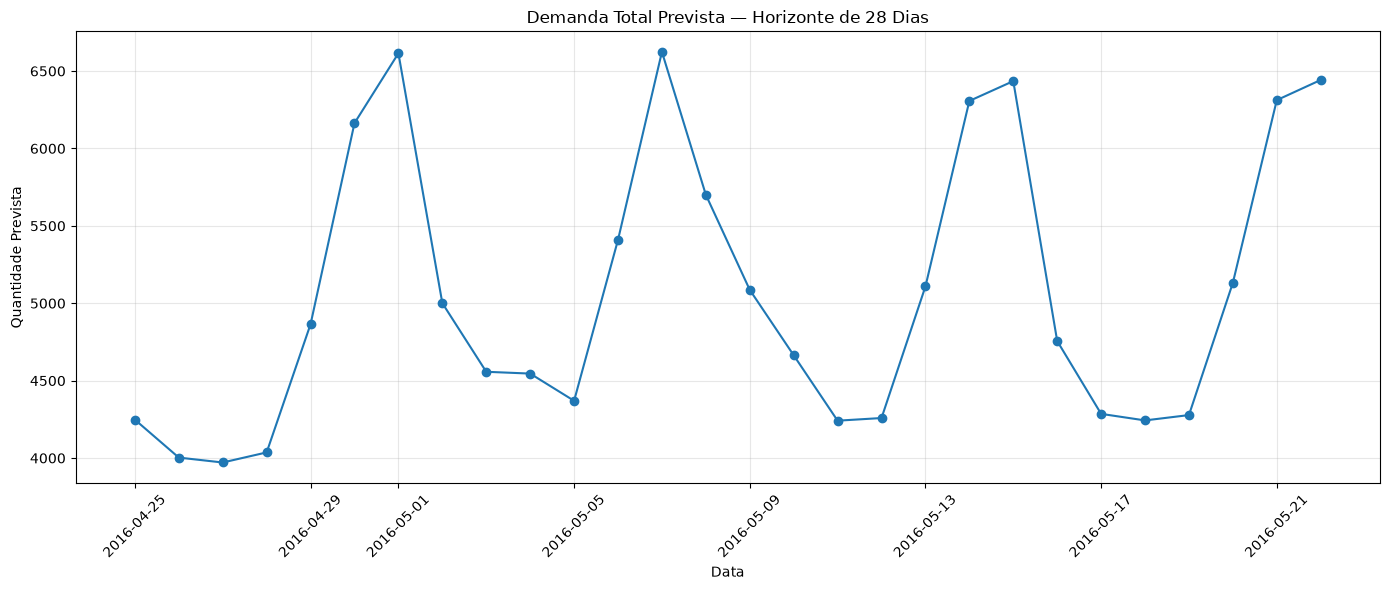

In [34]:
# ============================================================
# VISUALIZAÇÃO DA DEMANDA PREVISTA AO LONGO DO HORIZONTE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_by_day["date"],
    forecast_by_day["total_prediction"],
    marker="o"
)

plt.title("Demanda Total Prevista — Horizonte de 28 Dias")
plt.xlabel("Data")
plt.ylabel("Quantidade Prevista")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [35]:
# ============================================================
# ANÁLISE DOS ITENS COM MAIOR DEMANDA PREVISTA
# ============================================================

forecast_by_item = (
    forecast_final
    .groupby("item_id", as_index=False)
    .agg(
        total_prediction=("prediction", "sum"),
        mean_prediction=("prediction", "mean")
    )
    .sort_values("total_prediction", ascending=False)
)

print("Top 10 itens com maior demanda prevista:\n")

display(
    forecast_by_item.head(10)
)

Top 10 itens com maior demanda prevista:



,item_id,total_prediction,mean_prediction
702,FOODS_3_090,1506.733748,53.811920
732,FOODS_3_120,1269.951857,45.355423
1198,FOODS_3_586,1116.011597,39.857557
864,FOODS_3_252,1022.035787,36.501278
676,FOODS_3_064,718.491130,25.660398
1199,FOODS_3_587,656.003791,23.428707
894,FOODS_3_282,648.050549,23.144662
1293,FOODS_3_681,572.844368,20.458727
1325,FOODS_3_714,564.575716,20.163418
411,FOODS_2_197,563.284540,20.117305


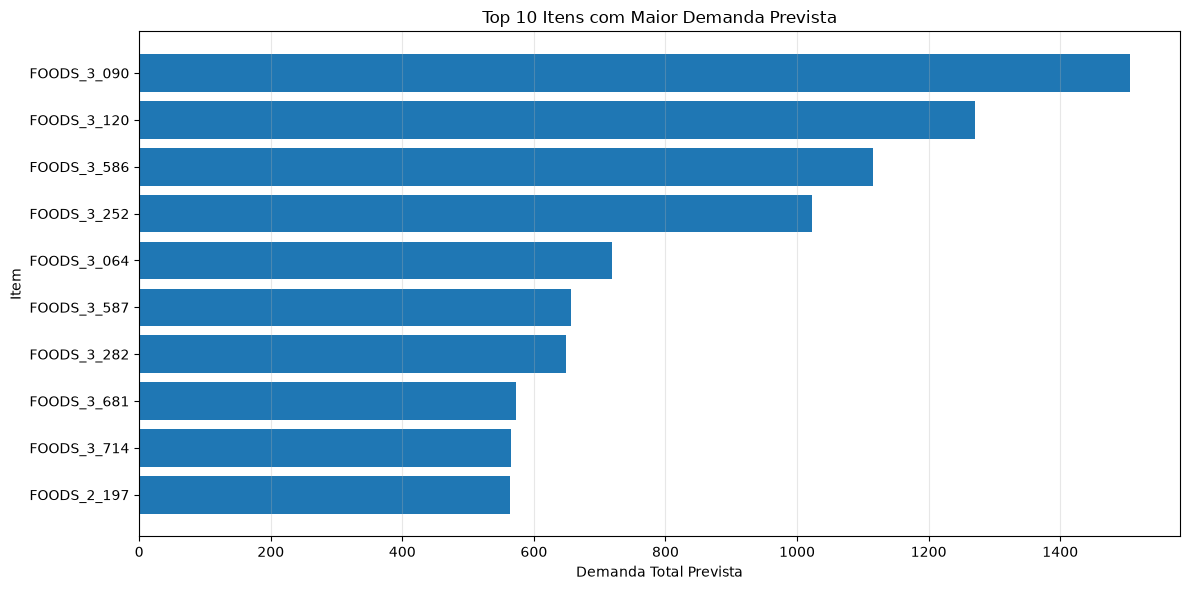

In [36]:
# ============================================================
# VISUALIZAÇÃO DOS TOP 10 ITENS COM MAIOR DEMANDA PREVISTA
# ============================================================

top_10_items = forecast_by_item.head(10).sort_values(
    "total_prediction",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_items["item_id"],
    top_10_items["total_prediction"]
)

plt.title("Top 10 Itens com Maior Demanda Prevista")
plt.xlabel("Demanda Total Prevista")
plt.ylabel("Item")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [37]:
# ============================================================
# EXPORTAÇÃO DO FORECAST FINAL
# ============================================================

OUTPUT_PATH = DATA_DIR / "processed" / "forecast_28_days.parquet"

forecast_final.to_parquet(
    OUTPUT_PATH,
    index=False
)

print("Forecast exportado com sucesso.")

print(f"\nArquivo salvo em:")
print(OUTPUT_PATH)

print(f"\nQuantidade de registros: {len(forecast_final):,}")

Forecast exportado com sucesso.

Arquivo salvo em:
c:\Projetos\retail-demand-forecasting\data\processed\forecast_28_days.parquet

Quantidade de registros: 85,372


In [38]:
# ============================================================
# VALIDAÇÃO DO ARQUIVO EXPORTADO
# ============================================================

forecast_saved = pd.read_parquet(
    DATA_DIR / "processed" / "forecast_28_days.parquet"
)

print("Forecast carregado novamente com sucesso.")

print(f"\nDimensões: {forecast_saved.shape}")

print("\nPeríodo previsto:")
print(f"Início: {forecast_saved['date'].min().date()}")
print(f"Fim: {forecast_saved['date'].max().date()}")

print(f"\nQuantidade de séries: "
      f"{forecast_saved[['item_id', 'store_id']].drop_duplicates().shape[0]:,}")

print(f"\nQuantidade total de registros: {len(forecast_saved):,}")

print("\nPrimeiras linhas:")
display(forecast_saved.head())

Forecast carregado novamente com sucesso.

Dimensões: (85372, 5)

Período previsto:
Início: 2016-04-25
Fim: 2016-05-22

Quantidade de séries: 3,049

Quantidade total de registros: 85,372

Primeiras linhas:


,item_id,store_id,date,d,prediction
0,FOODS_1_001,CA_1,2016-04-25,d_1914,0.950549
1,FOODS_1_002,CA_1,2016-04-25,d_1914,0.446481
2,FOODS_1_003,CA_1,2016-04-25,d_1914,0.704785
3,FOODS_1_004,CA_1,2016-04-25,d_1914,0.173419
4,FOODS_1_005,CA_1,2016-04-25,d_1914,1.209045


# ============================================================
# CONCLUSÕES E INSIGHTS DO FORECASTING
# ============================================================

## Resultado do Forecasting

O modelo LightGBM foi utilizado para gerar previsões de demanda para um horizonte futuro de 28 dias.

O processo utilizou uma abordagem de forecasting recursivo, onde as previsões geradas são incorporadas à memória de vendas para permitir o cálculo das features temporais dos períodos seguintes.

### Resultados principais

- Horizonte de previsão: **28 dias**
- Período previsto: **25/04/2016 a 22/05/2016**
- Quantidade de séries previstas: **3.049**
- Total de previsões geradas: **85.372**
- Modelo utilizado: **LightGBM**
- MAE do modelo: **1.035**
- RMSE do modelo: **1.997**

## Insights de negócio

A análise da demanda agregada mostrou um comportamento periódico ao longo do horizonte de previsão, com variações consistentes entre os dias da semana.

Também foram identificados os produtos com maior demanda prevista, permitindo priorizar itens que podem exigir maior atenção no planejamento de estoque.

O item **FOODS_3_090** apresentou a maior demanda total prevista durante o período, seguido pelos itens **FOODS_3_120** e **FOODS_3_586**.

## Próximas aplicações

O resultado deste forecasting pode ser utilizado para apoiar decisões relacionadas a:

- Planejamento de estoque;
- Reposição de produtos;
- Priorização de itens com maior demanda;
- Planejamento operacional;
- Análise de capacidade e abastecimento.

O forecast final foi exportado para:

`data/processed/forecast_28_days.parquet`

# ============================================================
# FIM DO NOTEBOOK 06 — FORECASTING
# ============================================================